In [492]:
import sys
sys.path.append("/project/src")

In [526]:
from coxmodel import CoxPH
from lifelines.utils import concordance_index
from lifelines.exceptions import ConvergenceWarning
from lifelines import KaplanMeierFitter
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score, validation_curve
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wandb
import seaborn as sns
import joblib
import warnings
from scipy.stats import randint, uniform, loguniform
from sklearn.utils.class_weight import compute_sample_weight
from sksurv.metrics import integrated_brier_score, cumulative_dynamic_auc, brier_score
from sksurv.util import Surv
from sklearn.metrics import mean_squared_error
from lifelines.statistics import multivariate_logrank_test, pairwise_logrank_test

from preprocessing import (
    split_features_target,
    build_survival_target,
    low_missingness_complete_case_analysis,
    concat_features_target,
    decode_preprocessed_feature_name,
    SURVIVAL_EVENT_COL,
    SURVIVAL_TIME_COL,
)

In [494]:
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive')
    train_df_csv = "/content/drive/MyDrive/bachelor/nacc_train_reduced.csv"
    test_df_csv = "/content/drive/MyDrive/bachelor/nacc_test.csv"
else:
    train_df_csv = "./data/nacc_train_reduced.csv"
    test_df_csv = "./data/nacc_test.csv"

In [495]:
train_df = pd.read_csv(train_df_csv, delimiter=',')
test_df = pd.read_csv(test_df_csv, delimiter=',')

/tmp/ipykernel_7384/2510053026.py:2: DtypeWarning: Columns (4,8,27,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,190,193,195,201,203,205,207,209,211,217,219,223,227,233,235,237,245,370,372,394,405,545,576,601,672,689,706,760,763,805,813,814,826,851,854) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv(test_df_csv, delimiter=',')


In [496]:
train_X, train_y = split_features_target(train_df)

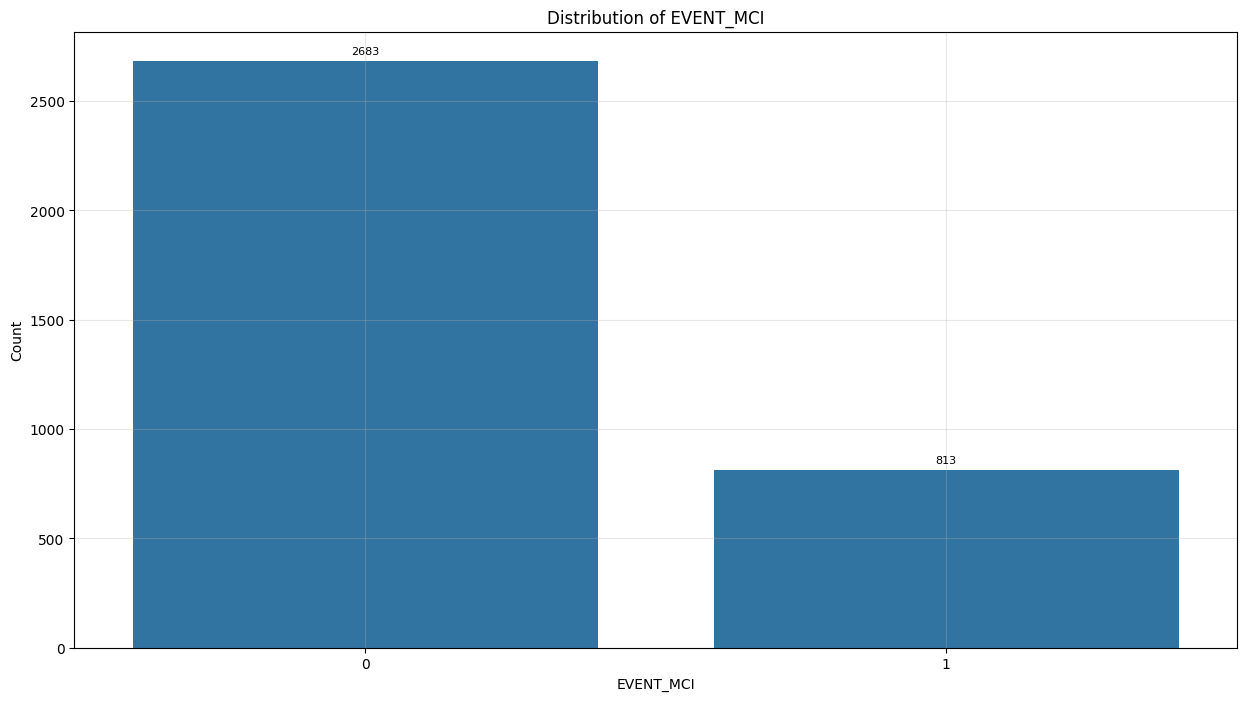

In [527]:
plt.figure(figsize=(15, 8))
bars = sns.barplot(x=test_df['EVENT_MCI'].value_counts().index, y=test_df['EVENT_MCI'].value_counts().values)
for bar in bars.containers:
    ax = bars.axes
    ax.bar_label(bar, padding=3, fontsize=8)
plt.title('Distribution of EVENT_MCI')
plt.xlabel('EVENT_MCI')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

In [528]:
test_df['EVENT_MCI'].value_counts(normalize=True)

EVENT_MCI
0    0.767449
1    0.232551
Name: proportion, dtype: float64

# Cross-Validation results

In [497]:
cox_pipeline = joblib.load("joblib-storage/cox_best_pipeline.joblib")
preprocessor = cox_pipeline.named_steps['preprocessor']
cox = cox_pipeline.named_steps['model']

In [498]:
cv_cindex = joblib.load("joblib-storage/cox_best_cv_cindex.joblib")
cv_cindex_std = joblib.load("joblib-storage/cox_best_cv_cindex_std.joblib")
print(f"Best CV C-index: {cv_cindex:.4f} ± {cv_cindex_std:.4f}")

Best CV C-index: 0.7660 ± 0.0191


# Evaluaition on test dataset

In [499]:
fitted_low_missingness_cols = preprocessor.get_low_missingness_cols()
test_preprepared = low_missingness_complete_case_analysis(test_df, low_missingness_columns=fitted_low_missingness_cols)
test_X_raw, test_y = split_features_target(test_preprepared)
test_X = preprocessor.transform(test_X_raw)

Complete-case analysis on low-missing columns
Dropping useless columns and columns represented the MCI diagnosis
Creating missingness indicator


In [500]:
test_events = test_y[SURVIVAL_EVENT_COL].astype(bool)
test_times = test_y[SURVIVAL_TIME_COL]

## Test c-index

In [501]:
cindex_test = cox.score(test_X, test_y)
print(f"Test C-index: {cindex_test:.4f}")

Test C-index: 0.7571


## Test IBS

In [502]:
event_min_time = test_times[test_events].min()
event_max_time = test_times[test_events].max()
print(f"Event times range from {event_min_time:.2f} to {event_max_time:.2f} years")

Event times range from 0.85 to 18.17 years


In [503]:
times_ibs = np.linspace(event_min_time, event_max_time, 100)

In [504]:
surv_probs_by_time = cox.predict_survival_function(test_X, times=times_ibs)
surv_probs_by_time.shape

(100, 1321)

In [505]:
surv_matrix = surv_probs_by_time.values.T
surv_matrix.shape

(1321, 100)

In [506]:
# IBS expect matric in format (n_patients, n_timepoints), so we need to transpose the matrix
T_surv_matrix = surv_probs_by_time.values.T

ibs = integrated_brier_score(train_y, test_y, T_surv_matrix, times_ibs)
print(f"Integrated Brier Score: {ibs:.4f}")

# wandb.log({"eval/integrated_brier_score": ibs})

Integrated Brier Score: 0.1904


## Test KM and Survival curve

In [507]:
kmf = KaplanMeierFitter()
kmf.fit(test_times, event_observed=test_events)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 1321 total observations, 1008 right-censored observations>

In [508]:
predicted_surv = cox.predict_survival_function(test_X).mean(axis=1)
predicted_surv.head(5)

0.145    0.999682
0.468    0.999364
0.652    0.999364
0.690    0.998728
0.747    0.998410
dtype: float64

In [509]:
test_times_min = test_times.min()
test_times_max = test_times.max()
times_to_plot = np.linspace(test_times_min, test_times_max, 100)

In [510]:
brier_times = np.arange(int(test_times_min)+1, int(test_times_max)+1)
brier_score_df = cox.predict_survival_function(test_X, times=brier_times)
brier_scores_T = brier_score_df.values.T

_, brier_scores = brier_score(train_y, test_y, brier_scores_T, brier_times)
brier_scores

array([0.01094734, 0.07105634, 0.09828925, 0.1202027 , 0.13594819,
       0.14900603, 0.15647641, 0.1616567 , 0.16838335, 0.18340046,
       0.21023754, 0.2221452 , 0.2369177 , 0.24224569, 0.26567342,
       0.28145177, 0.2828    , 0.29629594])

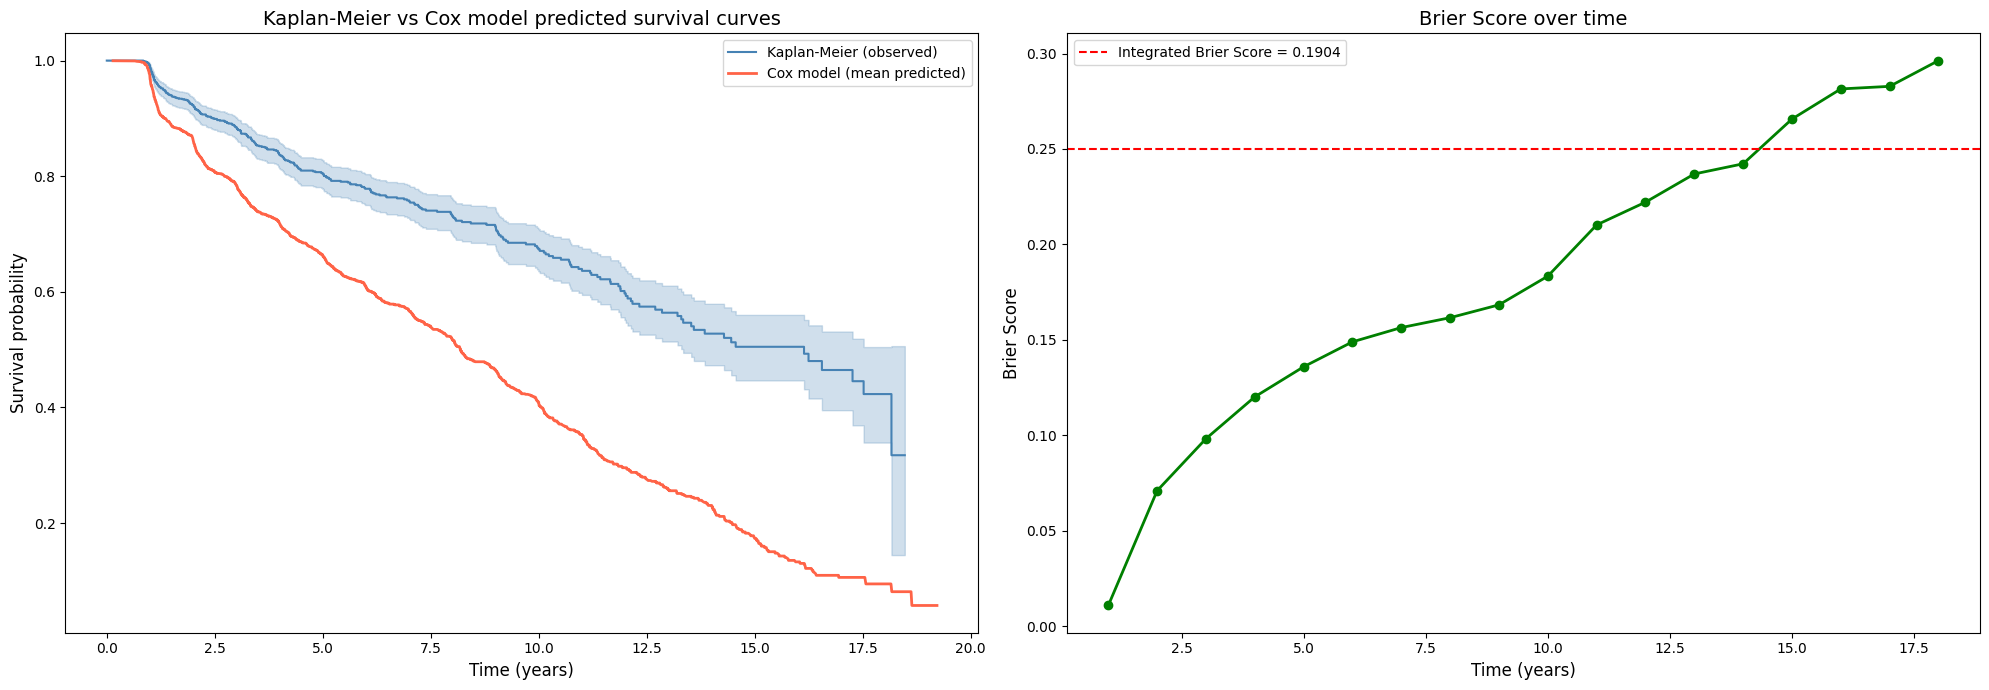

In [511]:
fig, ax = plt.subplots(1, 2, figsize=(20, 7))
kmf.plot_survival_function(ax=ax[0], label="Kaplan-Meier (observed)", color="steelblue")
ax[0].plot(predicted_surv.index, predicted_surv.values, color="tomato", linewidth=2, label="Cox model (mean predicted)")
ax[0].set_xlabel("Time (years)", fontsize=12)
ax[0].set_ylabel("Survival probability", fontsize=12)
ax[0].set_title("Kaplan-Meier vs Cox model predicted survival curves", fontsize=14)
ax[0].legend()  

ax[1].plot(brier_times, brier_scores, color="green", marker="o", linewidth=2)
ax[1].axhline(0.25, color="red", linestyle="--", label=f"Integrated Brier Score = {ibs:.4f}")
ax[1].set_xlabel("Time (years)", fontsize=12)
ax[1].set_ylabel("Brier Score", fontsize=12)
ax[1].set_title("Brier Score over time", fontsize=14)
ax[1].legend()
plt.tight_layout()
plt.show()

In [512]:
times = np.linspace(test_times_min, test_times_max, 100)
pred_surv = cox.predict_survival_function(test_X, times=times).values.T
predicted_mean = np.mean(pred_surv, axis=0)
kmf_surv_scores = kmf.survival_function_at_times(times).values

abs_errors = np.abs(kmf_surv_scores - predicted_mean)

rmse      = np.sqrt(mean_squared_error(kmf_surv_scores, predicted_mean))
median_ae = np.median(abs_errors)
mean_ae   = np.mean(abs_errors)

print(f"RMSE:             {rmse:.4f}")
print(f"Median Abs Error: {median_ae:.4f}")
print(f"Mean Abs Error:   {mean_ae:.4f}")

RMSE:             0.2514
Median Abs Error: 0.2477
Mean Abs Error:   0.2313


## Risk groups

In [513]:
risk_scores = cox.predict_partial_hazard(test_X).values

risk_df = pd.DataFrame({
  "scores": risk_scores,
  "event": test_events,
  "duration": test_times
})
risk_df.head()

,scores,event,duration
0,1.401248,False,2.086
1,0.488200,False,14.541
2,0.848922,False,4.036
3,1.606801,True,3.211
4,0.252425,False,10.059


In [514]:
stable_patients = risk_df[risk_df["event"] == False].copy()
converted_patients = risk_df[risk_df["event"] == True].copy()
stable_patients_scores = stable_patients["scores"]
converted_patients_scores = converted_patients["scores"]

print(f"cMCI risk scores: min={stable_patients_scores.min():.2f}, max={stable_patients_scores.max():.2f}, median={stable_patients_scores.median():.2f}")
print(f"pMCI risk scores: min={converted_patients_scores.min():.2f}, max={converted_patients_scores.max():.2f}, median={converted_patients_scores.median():.2f}")

cMCI risk scores: min=0.22, max=12.34, median=0.91
pMCI risk scores: min=0.28, max=12.94, median=1.30


In [515]:
NUMBER_OF_BINS = 80

In [516]:
bin_edges = np.linspace(converted_patients["scores"].min(), converted_patients["scores"].max(), NUMBER_OF_BINS + 1)
low_medium_cutoff = np.percentile(converted_patients["scores"], 25)
medium_high_cutoff = np.percentile(converted_patients["scores"], 75)

low_risk = converted_patients[converted_patients["scores"] <= low_medium_cutoff]['scores'].values
medium_risk = converted_patients[(converted_patients["scores"] > low_medium_cutoff) & ( converted_patients["scores"] <= medium_high_cutoff)]['scores'].values
high_risk = converted_patients[converted_patients["scores"] > medium_high_cutoff]['scores'].values

print(f"Low risk group:    {len(low_risk)} patients")
print(f"Medium risk group: {len(medium_risk)} patients")
print(f"High risk group:   {len(high_risk)} patients")

Low risk group:    79 patients
Medium risk group: 156 patients
High risk group:   78 patients


In [517]:
LOW_RISK_GROUP_INDICATOR = 0
MEDIUM_RISK_GROUP_INDICATOR = 1
HIGH_RISK_GROUP_INDICATOR = 2

def assign_patient_to_risk_group(score, low_cutoff, high_cutoff):
    if score <= low_cutoff:
        return LOW_RISK_GROUP_INDICATOR
    elif score <= high_cutoff:
        return MEDIUM_RISK_GROUP_INDICATOR
    else:
        return HIGH_RISK_GROUP_INDICATOR

In [518]:
converted_patients["risk_group"] = converted_patients["scores"].apply(lambda s: assign_patient_to_risk_group(s, low_medium_cutoff, medium_high_cutoff))
converted_patients.head()

,scores,event,duration,risk_group
3,1.606801,True,3.211,1
6,1.146712,True,8.030,1
8,2.547264,True,1.916,2
14,3.870185,True,1.793,2
15,8.707221,True,2.012,2


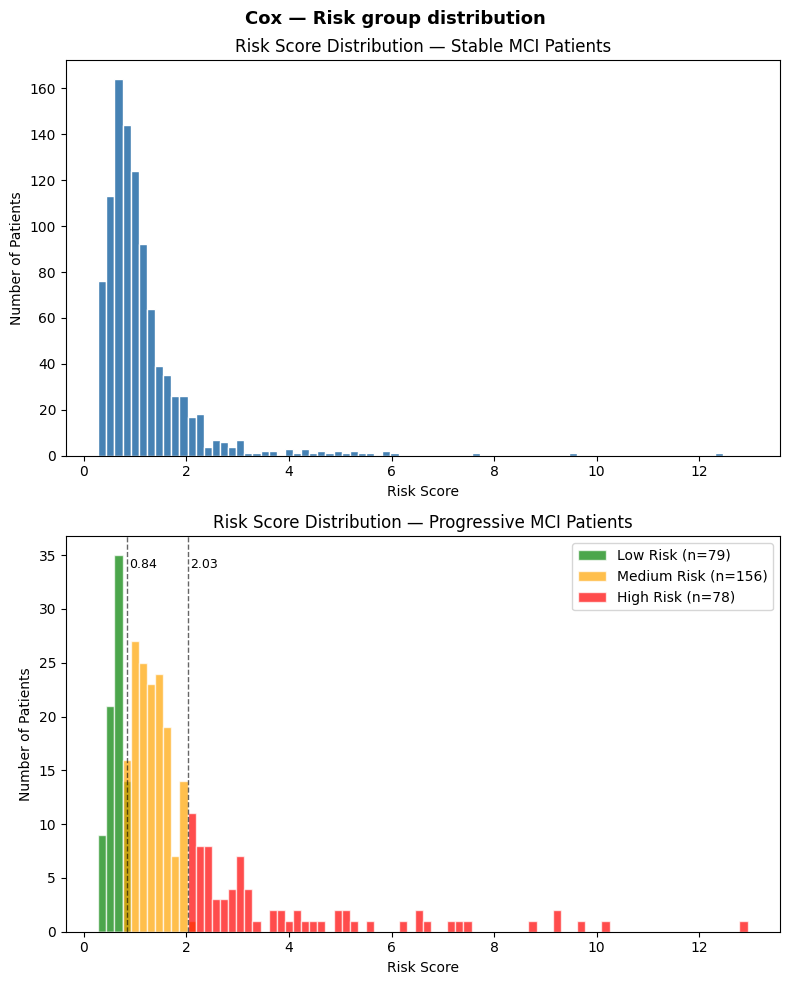

In [519]:
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

axes[0].hist(stable_patients_scores, bins=bin_edges, color="steelblue", edgecolor="white")
axes[0].set_title("Risk Score Distribution — Stable MCI Patients", fontsize=12)
axes[0].set_xlabel("Risk Score", fontsize=10)
axes[0].set_ylabel("Number of Patients", fontsize=10)

axes[1].hist(low_risk, bins=bin_edges, color="green", label=f"Low Risk (n={len(low_risk)})", edgecolor="white", alpha=0.7)
axes[1].hist(medium_risk, bins=bin_edges, color="orange", label=f"Medium Risk (n={len(medium_risk)})", edgecolor="white", alpha=0.7)
axes[1].hist(high_risk, bins=bin_edges, color="red", label=f"High Risk (n={len(high_risk)})", edgecolor="white", alpha=0.7)
axes[1].legend(fontsize=10)
axes[1].set_title("Risk Score Distribution — Progressive MCI Patients", fontsize=12)
axes[1].set_xlabel("Risk Score", fontsize=10)
axes[1].set_ylabel("Number of Patients", fontsize=10)

axes[1].axvline(low_medium_cutoff, color='black', linestyle='--', linewidth=1, alpha=0.6)
axes[1].axvline(medium_high_cutoff, color='black', linestyle='--', linewidth=1, alpha=0.6)
ymax = axes[1].get_ylim()[1]
axes[1].text(low_medium_cutoff + 0.05, ymax * 0.92, f'{low_medium_cutoff:.2f}', fontsize=9, color='black')
axes[1].text(medium_high_cutoff + 0.05, ymax * 0.92, f'{medium_high_cutoff:.2f}', fontsize=9, color='black')

plt.suptitle("Cox — Risk group distribution", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("risk_groups_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Analyse significance of group separation

In [520]:
overall = multivariate_logrank_test(
    converted_patients['duration'],
    converted_patients['risk_group'],
    converted_patients['event']
)
overall.print_summary()
print(f"Overall log-rank p-value: {overall.p_value:.20f}")

pairwise = pairwise_logrank_test(
    converted_patients['duration'],
    converted_patients['risk_group'],
    converted_patients['event']
)
pairwise.print_summary()

Overall log-rank p-value: 0.00000000000000004792


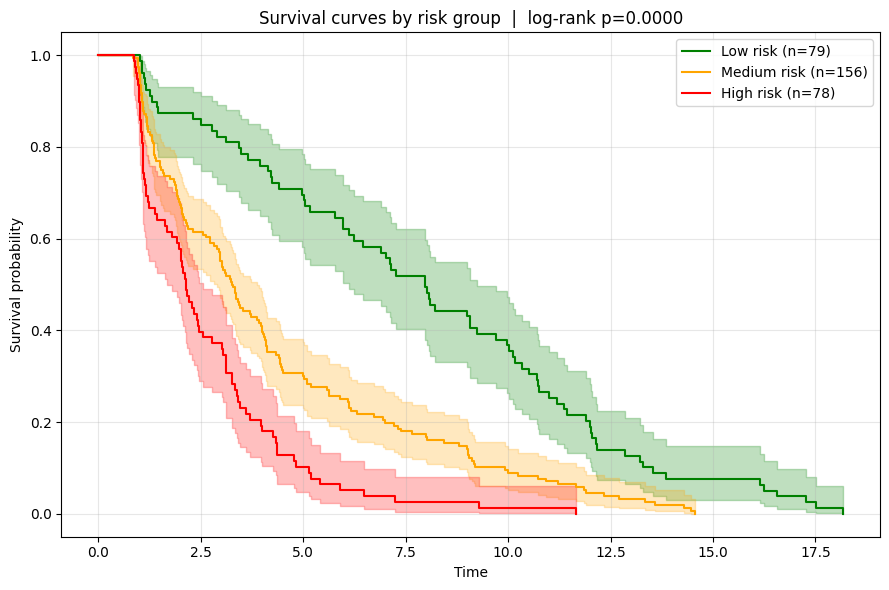

In [521]:
fig, ax = plt.subplots(figsize=(9, 6))

colors = {
    LOW_RISK_GROUP_INDICATOR: {"color": 'green', "name": "Low risk"},
    MEDIUM_RISK_GROUP_INDICATOR: {"color": 'orange', "name": "Medium risk"},
    HIGH_RISK_GROUP_INDICATOR: {"color": 'red', "name": "High risk"}
}
kmf = KaplanMeierFitter()

for group in [LOW_RISK_GROUP_INDICATOR, MEDIUM_RISK_GROUP_INDICATOR, HIGH_RISK_GROUP_INDICATOR]:
    mask = converted_patients['risk_group'] == group
    kmf.fit(
        converted_patients.loc[mask, 'duration'],
        converted_patients.loc[mask, 'event'],
        label=f'{colors[group]["name"]} (n={mask.sum()})'
    )
    kmf.plot_survival_function(ax=ax, ci_show=True, color=colors[group]["color"])

ax.set_xlabel("Time")
ax.set_ylabel("Survival probability")
ax.set_title(f"Survival curves by risk group  |  log-rank p={overall.p_value:.4f}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Time dependent ROC-AUC

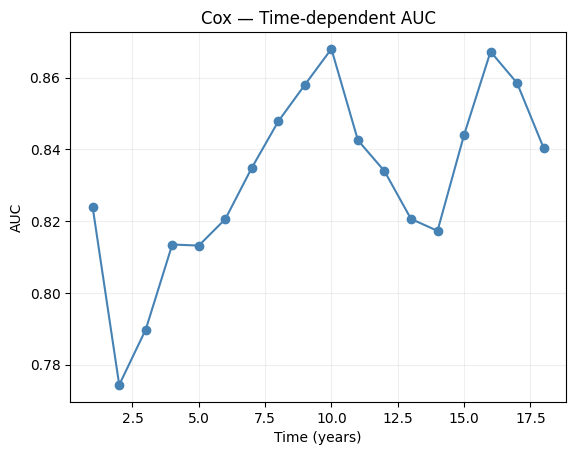

AUC at 1 year(s): 0.8238
AUC at 2 year(s): 0.7743
AUC at 3 year(s): 0.7898
AUC at 4 year(s): 0.8135
AUC at 5 year(s): 0.8132
AUC at 6 year(s): 0.8206
AUC at 7 year(s): 0.8349
AUC at 8 year(s): 0.8478
AUC at 9 year(s): 0.8580
AUC at 10 year(s): 0.8680
AUC at 11 year(s): 0.8425
AUC at 12 year(s): 0.8339
AUC at 13 year(s): 0.8206
AUC at 14 year(s): 0.8173
AUC at 15 year(s): 0.8440
AUC at 16 year(s): 0.8672
AUC at 17 year(s): 0.8585
AUC at 18 year(s): 0.8404
Mean AUC:          0.8255


In [525]:
times_roc   = np.arange(int(test_times_min)+1, int(test_times_max) + 1)
risk_scores = cox.predict_partial_hazard(test_X).values
auc_scores, mean_auc = cumulative_dynamic_auc(train_y, test_y, risk_scores, times_roc)

plt.plot(times_roc, auc_scores, marker='o', color='steelblue')
plt.xlabel("Time (years)")
plt.ylabel("AUC")
plt.title("Cox — Time-dependent AUC")
plt.grid(True, alpha=0.2)

plt.show()

for t, a in zip(times_roc, auc_scores):
    print(f"AUC at {t:.0f} year(s): {a:.4f}")
print(f"Mean AUC:          {mean_auc:.4f}")